In [1]:
import secml
from secml.array import CArray
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Albi utils
from utils_attacks import *
from utils_CP import *
from utils import * 

## 2D gaussian blob dataset

In [2]:
random_state = 999

n_features = 2  # Number of features
n_samples = 50000  # Number of samples
centers = [[-1, +1], [+1, -1]]  # Centers of the clusters
cluster_std = 1.0 # Standard deviation of the clusters

from secml.data.loader import CDLRandomBlobs
dataset = CDLRandomBlobs(n_features=n_features, 
                         centers=centers, 
                         cluster_std=cluster_std,
                         n_samples=n_samples,
                         random_state=random_state).load()

In [3]:
n_tr = 5000
n_vl = 5000 # Nuber of Validation samples (for Platt scaling)
n_cl = 5000 # Number of calibration set samples
n_lr = n_tr + n_vl + n_cl  # Number of learning set samples
n_ts = 2500  # Number of test set samples

# Split in training and test
from secml.data.splitter import CTrainTestSplit
splitter_lr_ts = CTrainTestSplit(
    train_size=n_lr, test_size=n_ts, random_state=random_state)

lr, ts = splitter_lr_ts.split(dataset)

splitter_tr_cl = CTrainTestSplit(
    train_size=n_tr + n_vl, test_size=n_cl, random_state=random_state)

tr_vl, cl = splitter_tr_cl.split(lr)

splitter_tr_vl = CTrainTestSplit(
    train_size = n_tr, test_size=n_vl, random_state=random_state)

tr, vl = splitter_tr_vl.split(tr_vl)

# Normalize the data
from secml.ml.features import CNormalizerMinMax
nmz = CNormalizerMinMax()
tr.X = nmz.fit_transform(tr.X)
ts.X = nmz.transform(ts.X)
cl.X = nmz.transform(cl.X)
vl.X = nmz.transform(vl.X)

# Shuffle data
rng = np.random.default_rng(seed=999)  
shuffled_indices_tr = rng.permutation(n_tr).tolist()  
tr.X = tr[shuffled_indices_tr, :].X 
tr.Y = tr[shuffled_indices_tr,:].Y    

rng = np.random.default_rng(seed=199)  
shuffled_indices_ts = rng.permutation(n_ts).tolist()  
ts.X = ts[shuffled_indices_ts, :].X 
ts.Y = ts[shuffled_indices_ts,:].Y    

rng = np.random.default_rng(seed=299)  
shuffled_indices_cl = rng.permutation(n_cl).tolist()  
cl.X = cl[shuffled_indices_cl, :].X 
cl.Y = cl[shuffled_indices_cl,:].Y    

rng = np.random.default_rng(seed=399)  
shuffled_indices_val = rng.permutation(n_vl).tolist()  
vl.X = vl[shuffled_indices_val, :].X 
vl.Y = vl[shuffled_indices_val,:].Y    


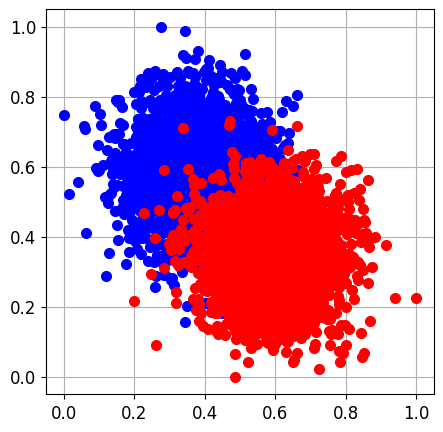

In [4]:
from secml.figure import CFigure
%matplotlib inline

fig = CFigure(width=5, height=5)

# Convenience function for plotting a dataset
fig.sp.plot_ds(tr)

fig.show()

## Training of an SVM classifier

Estimating the best training parameters...
The best training parameters are:  [('C', 0.1)]
Accuracy on test set: 91.12%


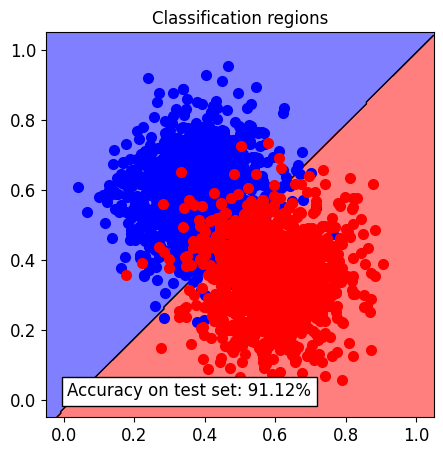

In [5]:
# Creation of the multiclass classifier
from secml.ml.classifiers import CClassifierSVM
from secml.ml.kernels import CKernelRBF
#svm = CClassifierSVM(kernel=CKernelRBF())

svm = CClassifierSVM()

# Parameters for the Cross-Validation procedure
#xval_params = {'C': [0.1, 1, 10], 'kernel.gamma': [1, 10, 100]}
xval_params = {'C': [0.1, 1, 10]}

# Let's create a 3-Fold data splitter
from secml.data.splitter import CDataSplitterKFold
xval_splitter = CDataSplitterKFold(num_folds=3, random_state=random_state)

# Metric to use for training and performance evaluation
from secml.ml.peval.metrics import CMetricAccuracy
metric = CMetricAccuracy()

# Select and set the best training parameters for the classifier
print("Estimating the best training parameters...")
best_params = svm.estimate_parameters(
    dataset=tr, 
    parameters=xval_params, 
    splitter=xval_splitter, 
    metric=metric, 
    perf_evaluator='xval'
)

print("The best training parameters are: ", 
      [(k, best_params[k]) for k in sorted(best_params)])

# We can now fit the classifier
svm.fit(tr.X, tr.Y)

# Compute predictions on a test set
y_pred = svm.predict(ts.X)

# Evaluate the accuracy of the classifier
acc = metric.performance_score(y_true=ts.Y, y_pred=y_pred)

print("Accuracy on test set: {:.2%}".format(acc)),

fig = CFigure(width=5, height=5)

# Convenience function for plotting the decision function of a classifier
fig.sp.plot_decision_regions(svm, n_grid_points=200)

fig.sp.plot_ds(ts)
fig.sp.grid(grid_on=False)

fig.sp.title("Classification regions")
fig.sp.text(0.01, 0.01, "Accuracy on test set: {:.2%}".format(acc), 
            bbox=dict(facecolor='white'))

fig.show()

2025-09-20 16:31:27,981 - matplotlib.legend - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


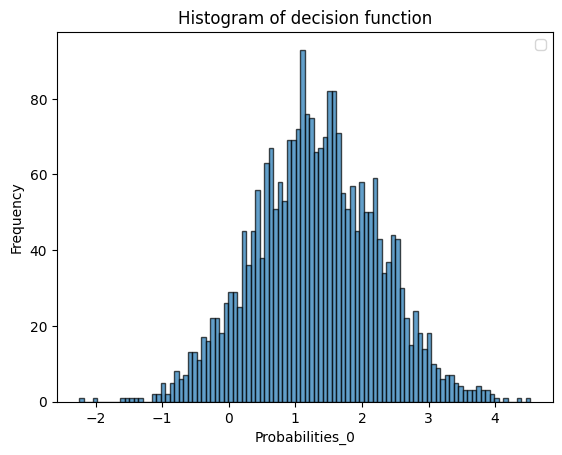

In [6]:
decision_scores = svm.decision_function(tr.X)[:, 0].tondarray()

indices_0 = tr.Y.tondarray() == 0
decision_scores_0 = decision_scores[indices_0]

plt.hist(decision_scores_0, bins=100, edgecolor='black', alpha=0.7)

# Adding labels, title, and legend
plt.xlabel('Probabilities_0')
plt.ylabel('Frequency')
plt.title('Histogram of decision function')
plt.legend()

# Show the plot
plt.show()

### Platt scaling

In [7]:
# 0 is the positive class

decision_scores = svm.decision_function(vl.X)[:, 0].tondarray()

from sklearn.linear_model import LogisticRegression

# Ground truth labels
y_true = vl.Y.tondarray() 

# Fit logistic regression for Platt scaling
platt_scaler = LogisticRegression()
platt_scaler.fit(decision_scores.reshape(-1,1), y_true)

probabilities_0 = platt_scaler.predict_proba(decision_scores.reshape(-1, 1))[:, 0] 

platt_labels = (probabilities_0 <= 0.5).astype(int)

platt_acc = metric.performance_score(y_true = vl.Y, y_pred=CArray(platt_labels))

print("Accuracy on test set: {:.2%}".format(platt_acc))

Accuracy on test set: 92.72%


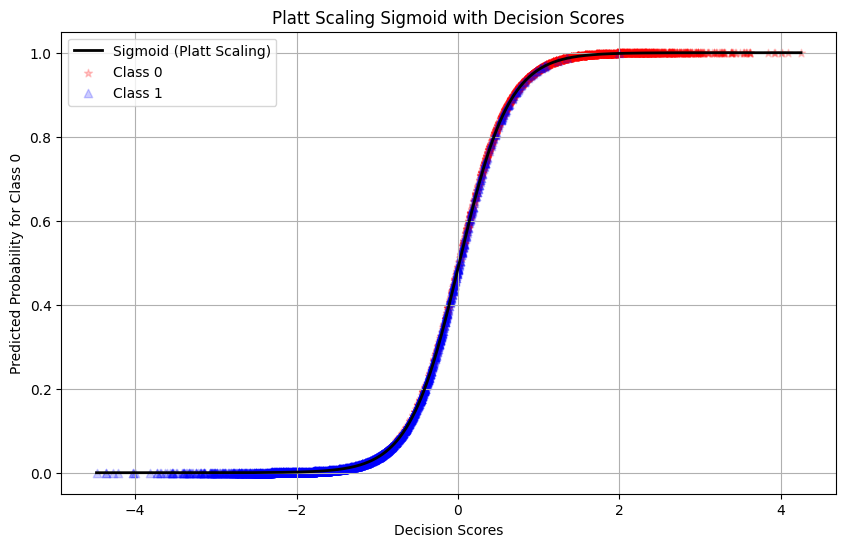

In [8]:
sorted_indices = np.argsort(decision_scores[:,0])
sorted_scores = decision_scores[sorted_indices]
sorted_probs = probabilities_0[sorted_indices]

plt.figure(figsize=(10, 6))
plt.plot(sorted_scores, sorted_probs, color="black", label="Sigmoid (Platt Scaling)", linewidth=2)

plt.scatter(decision_scores[y_true == 0], probabilities_0[y_true == 0], color="red", marker = '*', label="Class 0", alpha=0.2)
plt.scatter(decision_scores[y_true == 1], probabilities_0[y_true == 1], color="blue", marker = '^', label="Class 1", alpha=0.2)

plt.title("Platt Scaling Sigmoid with Decision Scores")
plt.xlabel("Decision Scores")
plt.ylabel("Predicted Probability for Class 0")
plt.legend()
plt.grid()
plt.show()

2025-09-20 16:31:32,444 - matplotlib.legend - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


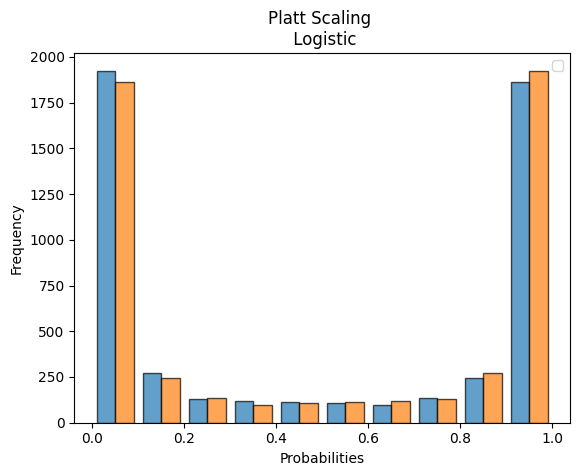

In [9]:
probabilities = platt_scaler.predict_proba(decision_scores) 

plt.hist(probabilities, bins=10, edgecolor='black', alpha=0.7)

# Adding labels, title, and legend
plt.xlabel('Probabilities')
plt.ylabel('Frequency')
plt.title('Platt Scaling \n Logistic')
plt.legend()

# Show the plot
plt.show()

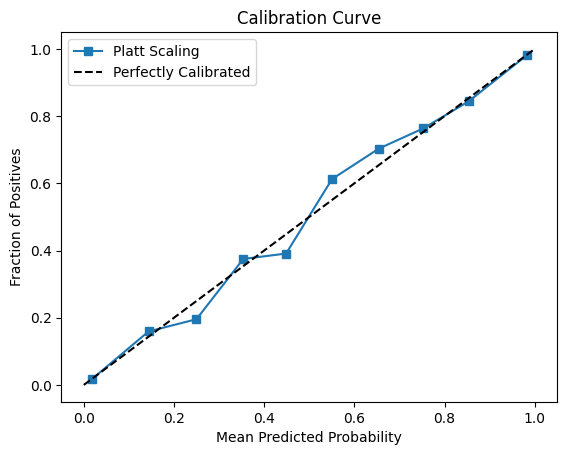

In [10]:
from sklearn.calibration import calibration_curve

probabilities = platt_scaler.predict_proba(decision_scores.reshape(-1, 1))

# Get predicted probabilities and true labels
y_pred_probs = probabilities[:, 1]  # Probabilities for the positive class
true_labels = y_true  # Ground truth labels

# Generate calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(true_labels, y_pred_probs, n_bins=10)

# Plot calibration curve
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Platt Scaling")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend()
plt.title("Calibration Curve")
plt.show()

## Perform the attack

Simple attack for linear SVM

$\delta^* = -(2y-1)\dfrac{\varepsilon}{||w||_2}w$

$\tilde x = x + \delta^*$

In [11]:
def attack_linear_SVM(x, y, w, epsilon):
    
    delta_star = -(epsilon/np.linalg.norm(w, ord=2))*(2*y-1)[:, np.newaxis]*w
    
    return x + CArray(delta_star)

In [12]:
def svm_f_x_y(x, y):

    return platt_scaler.predict_proba(svm.decision_function(x).tondarray()[:,0].reshape(-1, 1))[:, y.item()]     

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Error of the classifier 
y_test_pred = svm.predict(ts.X)
svm_error = 1 - np.sum(ts.Y.tondarray() == y_test_pred.tondarray()) / len(ts.Y.tondarray())

# Epsilon values
Epsilon = np.linspace(0, 1, 50)  # Generate 50 values between 0.01 and 1

# Array to store the percentage of successfully attacked points
success_rates = []

# Iterate over each epsilon value
for eps in Epsilon:
    # Perform the attack
    attacked_ts = attack_linear_SVM(ts.X, ts.Y.tondarray(), w.tondarray(), eps)
    
    # Predict with the attacked data
    y_pred_adv = svm.predict(attacked_ts)
    
    # Check how many points were misclassified
    success_count = np.sum(y_pred_adv.tondarray() != ts.Y.tondarray())  # Number of misclassified points
    total_points = len(ts.Y.tondarray())  # Total number of points in the dataset
    
    # Calculate the success rate (percentage)
    success_rate = (success_count / total_points) * 100
    success_rates.append(success_rate)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(Epsilon, success_rates, marker='o', linestyle='-', color='b', label='Attack Success Rate')

# Add a horizontal line for the SVM error
plt.axhline(y=svm_error * 100, color='red', linestyle='--', label='Classifier Error')

# Add labels, title, and legend
plt.xlabel('Epsilon')
plt.ylabel('Attack Success Rate (%)')
plt.title('Attack Success Rate vs Epsilon')
plt.grid(True)
plt.legend()

# Show the plot
plt.show()

NameError: name 'w' is not defined

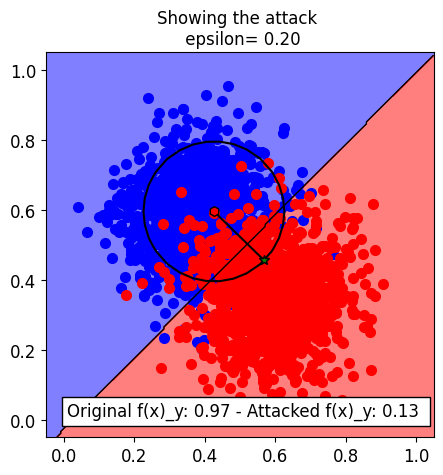

In [14]:
# getting y = wx + b
w = svm.w
b = svm.b

import random
random_int = random.randint(1, n_ts)

x = ts.X[random_int,:] 
y = ts.Y[0,random_int]

epsilon = .2
x_adv = attack_linear_SVM(x, y.tondarray(), w.tondarray(), epsilon)

y_pred_adv = svm.predict(x_adv)
        
f_x_y = svm_f_x_y(x,y.tondarray())     
f_x_adv_y = svm_f_x_y(x_adv,y.tondarray())
        
# Create a CFigure instance for visualization
fig = CFigure(width=5, height=5)

from secml.optim.constraints import CConstraintL2
constraint = CConstraintL2(center=x, radius=epsilon)

# Plot the dataset
fig.sp.plot_ds(ts)

# Function for plotting a constraint
fig.sp.plot_constraint(constraint)

pt_segment = CArray.append(x, x_adv, axis=0)
fig.sp.plot_path(pt_segment)

fig.sp.plot_decision_regions(svm, n_grid_points=200)

# Add legend and show
fig.sp.text(0.01, 0.01, "Original f(x)_y: {:.2f} - Attacked f(x)_y: {:.2f} ".format(f_x_y[0], f_x_adv_y[0]), 
            bbox=dict(facecolor='white'))
fig.sp.title("Showing the attack \n epsilon= {:.2f}".format(epsilon))

fig.show()

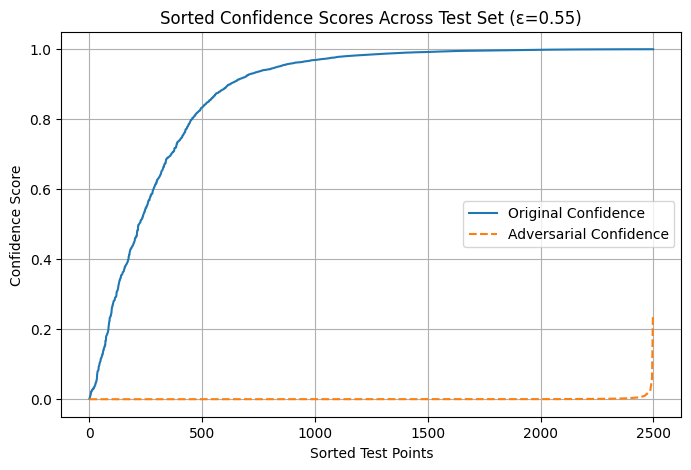

In [15]:
import numpy as np
import matplotlib.pyplot as plt

f_x_y_values = []
f_x_adv_y_values = []
epsilon = 0.55  # Adjust epsilon as needed

# Collect confidence scores for all test points
for i in range(n_ts):
    x = ts.X[i, :]
    y = ts.Y[0, i]
    
    # Compute original confidence score
    f_x_y = svm_f_x_y(x, y.tondarray())
    
    # Generate adversarial example and compute confidence score
    x_adv = attack_linear_SVM(x, y.tondarray(), w.tondarray(), epsilon)
    f_x_adv_y = svm_f_x_y(x_adv, y.tondarray())
    
    # Store values
    f_x_y_values.append(f_x_y[0])
    f_x_adv_y_values.append(f_x_adv_y[0])

# Convert to numpy arrays for sorting
f_x_y_values = np.array(f_x_y_values)
f_x_adv_y_values = np.array(f_x_adv_y_values)

# Sort the original confidence scores and reorder adversarial scores accordingly
sorted_indices = np.argsort(f_x_y_values)
f_x_y_sorted = f_x_y_values[sorted_indices]
f_x_adv_y_sorted = f_x_adv_y_values[sorted_indices]

# Plot the sorted confidence scores
plt.figure(figsize=(8, 5))
plt.plot(f_x_y_sorted, label="Original Confidence")
plt.plot(f_x_adv_y_sorted, label="Adversarial Confidence", linestyle='--')
plt.xlabel("Sorted Test Points")
plt.ylabel("Confidence Score")
plt.title(f"Sorted Confidence Scores Across Test Set (ε={epsilon})")
plt.legend()
plt.grid(True)
plt.show()


## Attack

In [24]:
cl_att = list(attack_linear_SVM(cl.X, cl.Y.tondarray(), w.tondarray(), eps).tondarray())
ts_att = list(attack_linear_SVM(ts.X, ts.Y.tondarray(), w.tondarray(), eps).tondarray())

## Conformal Prediction
# TOP K é DA SISTEMARE

In [18]:
def s(x, y, clf, method = 'lac'):
    
    if method == 'lac':
        
        decision_scores_0 = svm.decision_function(x)[:, 0].tondarray()
        probabilities = platt_scaler.predict_proba(decision_scores_0.reshape(-1,1))[0]

        return 1 - probabilities[y.item()]
    
    if method == 'top-k':
        
        decision_scores_0 = svm.decision_function(x)[:, 0].tondarray()
        probabilities = platt_scaler.predict_proba(decision_scores_0.reshape(-1,1))[0]
        ranked_indices = np.argsort(probabilities)[::-1]
        j = ranked_indices[np.where(ranked_indices == y.item())[0][0]]
        
        return j
        
    if method == 'aps':
        
        decision_scores_0 = svm.decision_function(x)[:, 0].tondarray()
        probabilities = platt_scaler.predict_proba(decision_scores_0.reshape(-1,1))[0]
        # Rank labels by decreasing probability
        ranked_indices = np.argsort(probabilities)[::-1]
        # Sum probabilities until reaching the true label
        cum_sum = 0
        for k, label in enumerate(ranked_indices):
            cum_sum += probabilities[label]
            if label == y.item():
                return cum_sum  # Return cumulative score at true label

        return 1.0  # Should never reach here
    
def compute_score(db, db2, clf, method = 'lac'):
    
    scores = []  

    for i in tqdm(range(db.X.shape[0]), desc="Computing scores...", unit="sample"):
        y = db[i,:].Y.tondarray()
        
        if isinstance(db2, list):
            
            x = db2[i]
            
        else:
            
            x = db2[i,:].X

        score = s(x,y, clf, method)

        scores.append(score)
    
    return scores  


digits = list(range(2))

def compute_CP(db, qhat, clf, method='lac', verbose=True):
    conformal_sets = []  # List to store conformal sets for each test point
    scores_list = []  # List to store scores for each test point
    
    if isinstance(db, list):
        n = len(db)
    else:
        n = db.X.shape[0]
        
    iterable = range(n) if not verbose else tqdm(range(n), desc="Computing CP sets", ncols=100)

    for i in iterable:
        if isinstance(db, list):
            x = db[i]
        else:
            x = db[i, :].X

        scores = {}  # Dictionary to store scores for all digits
        conformal_set = []

        if method == 'lac':
            for d in digits:
                score = s(x, CArray([d]), clf, method)
                scores[d] = score  # Store score
                if score <= qhat:
                    conformal_set.append(d)
                    
        elif method == 'top-k':
            
            qhat_k = np.ceil(qhat)
            
            decision_scores_0 = svm.decision_function(x)[:, 0].tondarray()
            probabilities = platt_scaler.predict_proba(decision_scores_0.reshape(-1,1))[0]
            ranked_indices = np.argsort(probabilities)[::-1]
            
            for d in ranked_indices:
                conformal_set.append(d)
                if ranked_indices[np.where(ranked_indices == d)[0][0]] == qhat_k:
                    break

        elif method == 'aps':
            
            # Get scores for all digits
            scores = {d: s(x, CArray([d]), clf, method) for d in digits}
            # Sort class indices by increasing score (higher confidence first)
            sorted_digits = sorted(scores, key=scores.get)
            # Build APS set: accumulate scores until threshold is reached
            for d in sorted_digits:
                conformal_set.append(d)
                if scores[d] >= qhat:  # Stop when reaching quantile
                    break

        else:
            raise ValueError("Unsupported method. Choose 'lac' or 'aps'.")

        conformal_sets.append(conformal_set)
        scores_list.append(scores)

    return conformal_sets, scores_list

def compute_covergae(dataset, conformal_sets):
    
    true_label_in_conformal_set = []
    n = dataset.X.shape[0]  # Assuming `dataset` is a list or similar iterable
    
    for i in range(n):
        y0 = dataset[i,:].Y
        conformal_set = conformal_sets[i]
        true_label_in_conformal_set.append(y0 in conformal_set)

    n_correct = sum(true_label_in_conformal_set)
    accuracy = n_correct / n * 100
    
    print(f"True label is in the conformal set for {n_correct}/{n} test samples ({accuracy:.2f}%).")
    
    return accuracy


def compute_set_sizes(dataset, conformal_sets, verbose=True):
    conformal_set_sizes = [len(conformal_set) for conformal_set in conformal_sets]

    max_size = 10  # Maximum size to consider
    counts = {size: conformal_set_sizes.count(size) for size in range(max_size + 1)}

    # Print only nonzero counts
    if verbose:
        for size, count in counts.items():
            if count > 0:
                print(f"Number of conformal sets with size {size}: {count}")

    return conformal_set_sizes

def compute_covergae_std(dataset, conformal_sets):
    
    true_label_in_conformal_set = []
    n = dataset.X.shape[0]  # Assuming `dataset` is a list or similar iterable
    
    for i in range(n):
        y0 = dataset[i,:].Y
        conformal_set = conformal_sets[i]
        true_label_in_conformal_set.append(y0 in conformal_set)

    vari = np.var(true_label_in_conformal_set)  # Compute mean coverage
    stdi = np.std(true_label_in_conformal_set)
    
    print(f"Coverage std ({stdi:.2f}).")
    
    return stdi

def mean_conformal_sets(conformal_sets):

    non_empty_sets = [set for set in conformal_sets if set] 

    set_sizes = [len(s) for s in non_empty_sets]
    
    print(f"Average set size: {np.mean(set_sizes)}")

    return np.mean(set_sizes) if set_sizes else 0 

def std_conformal_sets(conformal_sets):
    # Filter out empty sets
    non_empty_sets = [s for s in conformal_sets if s]
    
    # Compute set sizes
    set_sizes = [len(s) for s in non_empty_sets]
    
    # Calculate and print the standard deviation
    std_size = np.std(set_sizes) if set_sizes else 0
    print(f"Std set size: {std_size}")
    
    return std_size

def plot_conformal_histogram(conformal_set_sizes):
    """
    Plots a histogram of conformal set sizes, highlighting the 0 size bin in red.
    """
    # Ensure we include a bin for 0 class size
    conformal_set_sizes = [0 if size == 0 else size for size in conformal_set_sizes]
    bins = np.arange(0, max(conformal_set_sizes) + 2) - 0.5  # Add 0 bin

    plt.figure(figsize=(8, 6))
    plt.hist(conformal_set_sizes, bins=bins, edgecolor='black', rwidth=0.8, color='blue')

    # Highlight the bin for size 0 in red
    ax = plt.gca()
    ax.patches[0].set_facecolor('red')

    plt.title("Conformal Set Sizes", fontsize=14)
    plt.xlabel("Set Size (Number of Labels in Conformal Set)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(np.arange(0, max(conformal_set_sizes) + 2))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
def plot_calibration_curve(db, db2, calibration_scores, clf, alpha1 = 0.1, alpha2 = 0.9, steps = 50, method = 'lac'):
    """
    Plots the calibration curve: true label coverage vs. significance level (alpha).
    """
    probabilities, alphas = calibration_curve(db, db2, calibration_scores, clf, alpha1, alpha2, steps)
    
    plt.figure(figsize=(8, 6))
    plt.plot(alphas, probabilities, marker='o', label='True label probability')
    plt.plot(alphas, 1 - alphas, color='r', linestyle='--', label='Expected coverage (1 - alpha)')
    
    plt.title('True Label Coverage vs. Alpha', fontsize=14)
    plt.xlabel(r'$\alpha$ (Significance level)', fontsize=12)
    plt.ylabel('Probability of true label in conformal set', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
def calibration_curve(db, db2, calibration_scores, scores_list, clf, alpha1, alpha2, steps, method):
    """
    Computes the calibration curve for a given model using conformal prediction.
    The method can be 'lac' or 'aps' for LAC or APS methods respectively.
    
    Instead of recomputing CP sets, we filter them dynamically from `scores_list`.
    """
    if isinstance(db, list):
        n = len(db)
    else:
        n = db.X.shape[0]

    labels = np.array(db2.Y.tondarray())

    # Generate alpha values for the calibration curve
    alphas = np.linspace(alpha1, alpha2, steps)
    probabilities = []

    # Compute the calibration curve for different alpha levels
    for alpha in tqdm(alphas, desc="Plotting calibration curve", ncols=100):
        q_level = np.ceil((len(calibration_scores) + 1) * (1 - alpha)) / len(calibration_scores)
        qhat = np.quantile(calibration_scores, q_level, method='lower')

        # Generate conformal sets dynamically based on precomputed scores
        conformal_sets = []
        
        for scores in scores_list:  # Iterate over precomputed scores
            if method == 'lac':
                conformal_set = [d for d, score in scores.items() if score <= qhat]
                
            elif method == 'top-k':
                # scores should store predicted probabilities for each label
                sorted_digits = sorted(scores, key=scores.get, reverse=True)  # Descending order
                conformal_set = sorted_digits[:int(np.ceil(qhat))]  # Take top-k

                
            elif method == 'aps':
                sorted_digits = sorted(scores, key=scores.get, reverse=True)  # Sort by decreasing probability
                conformal_set = []
                cumulative_prob = 0
                for d in sorted_digits:
                    conformal_set.append(d)
                    cumulative_prob += scores[d]
                    if cumulative_prob >= qhat:  # qhat here acts as cumulative probability threshold
                        break
            else:
                raise ValueError("Unsupported method. Choose 'lac' or 'aps'.")
            
            conformal_sets.append(conformal_set)

        # Check if the true label is in the conformal set
        true_label_in_conformal_set = [
            1 if labels[i] in conformal_sets[i] else 0
            for i in range(n)
        ]

        # Compute the probability of the true label being in the conformal set
        n_correct = sum(true_label_in_conformal_set)
        probability = n_correct / n
        probabilities.append(probability)

    return probabilities, alphas
    
    
def plot_conformal_analysis(db, db2, conformal_set_sizes, calibration_scores, scores_list, clf, alpha1= 0.1, alpha2 = 0.9, steps = 50, method = 'lac', dataset_name = 'CIFAR10'):
    """
    Combines the conformal set size histogram and calibration curve into a single figure with two subplots.
    """
    
    sns.set_style("whitegrid")
    
    print("Plotting results...")
    # Compute the calibration curve values
    probabilities, alphas = calibration_curve(db, db2, calibration_scores, scores_list, clf, alpha1, alpha2, steps, method)

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

     # Subplot 1: Histogram of conformal set sizes
    conformal_set_sizes = [0 if size == 0 else size for size in conformal_set_sizes]
    bins = np.arange(0, max(conformal_set_sizes) + 2) - 0.5  # Ensure correct bin edges

    sns.histplot(conformal_set_sizes, bins=bins, ax=axes[0], color="royalblue", edgecolor="black", alpha=0.8)

    # Highlight the bin for size 0 in red
    bars = axes[0].patches
    if len(bars) > 0:
        bars[0].set_facecolor("red")

    axes[0].set_title(f"Conformal Set Sizes ({dataset_name})", fontsize=14)
    axes[0].set_xlabel("Set Size (Number of Labels in Conformal Set)", fontsize=12)
    axes[0].set_ylabel("Frequency", fontsize=12)
    axes[0].set_xticks(np.arange(0, max(conformal_set_sizes) + 2, max(1, len(set(conformal_set_sizes)) // 10)))
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)
    
    # Subplot 2: Calibration curve
    axes[1].plot(alphas, probabilities, marker='o', label='True label probability')
    axes[1].plot(alphas, 1 - alphas, color='r', linestyle='--', label='Expected coverage (1 - alpha)')
    axes[1].set_title('True Label Coverage vs. Alpha', fontsize=14)
    axes[1].set_xlabel(r'$\alpha$ (Significance level)', fontsize=12)
    axes[1].set_ylabel('Probability of true label in conformal set', fontsize=12)
    axes[1].legend()
    axes[1].grid(True)

    # Adjust layout
    plt.tight_layout()
    plt.show()    



In [19]:
random_int = random.randint(1, n_ts)

x = ts.X[random_int,:] 
y = ts.Y[0,random_int]
print("y true = ", y.item())
print("y pred = ", svm.predict(x).item())

x_adv = attack_linear_SVM(x, y.tondarray(), w.tondarray(), epsilon)

y_pred_adv = svm.predict(x_adv)
print("y pred adv = ", svm.predict(x_adv).item())

print('LAC score: ', s(x,y, svm, 'lac'))
print('LAC score attacked: ', s(x_adv,y, svm, 'lac'))

print('APS score: ', s(x,y, svm, 'aps'))
print('APS score attacked: ', s(x_adv,y, svm, 'aps'))

print('TOP-k score: ', s(x,y, svm, 'top-k'))
print('TOP-k score attacked: ', s(x_adv,y, svm, 'top-k'))

y true =  1
y pred =  1
y pred adv =  0
LAC score:  0.00010690808347557645
LAC score attacked:  0.9965243244156676
APS score:  0.9998930919165244
APS score attacked:  1.0
TOP-k score:  1
TOP-k score attacked:  1


In [20]:
Method = ['aps']#['lac', 'top-k', 'aps']
D = {}

for method in Method:
    cl_cs_scores  = compute_score(cl, cl, svm, method)
    cl_att_scores = compute_score(cl, cl_att, svm, method)
    ts_cs_scores  = compute_score(ts, ts, svm, method)
    ts_att_scores = compute_score(ts, ts_att, svm, method)
    
    D[method] = {
        'cl_cs': cl_cs_scores,
        'cl_att': cl_att_scores,
        'ts_cs': ts_cs_scores,
        'ts_att': ts_att_scores
    }


Computing scores...: 100%|██████████| 2500/2500 [00:01<00:00, 2119.72sample/s]


In [25]:
method

'aps'


Method: aps
Classic quantile: 0.998209616264921
Attacked quantile: 0.998209616264921


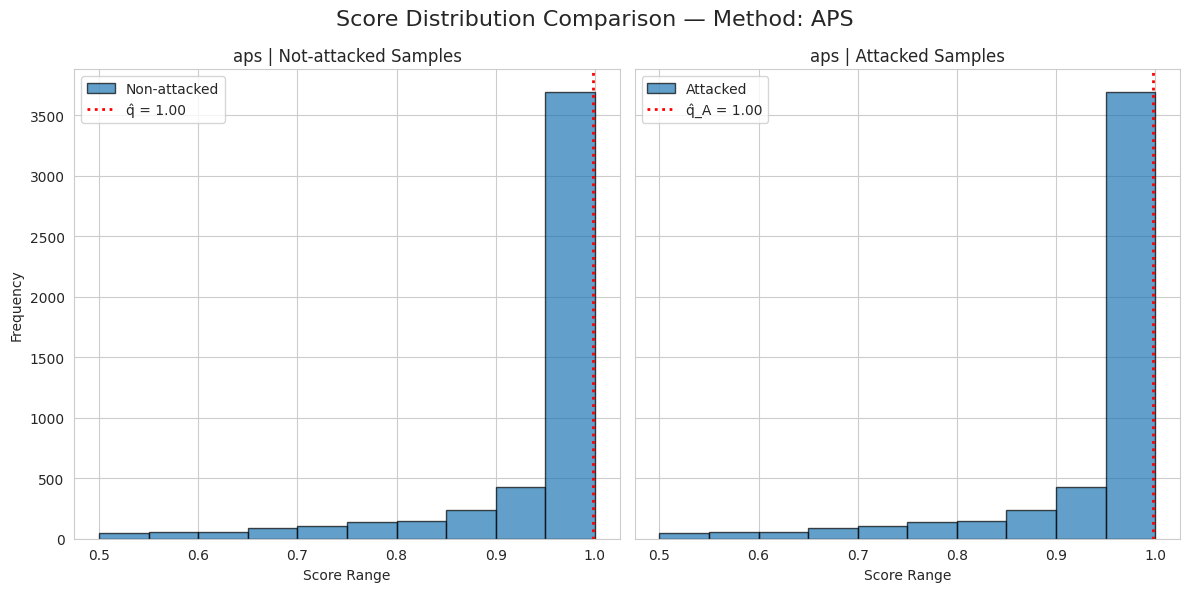

Computing CP sets: 100%|██████████████████████████████████████| 2500/2500 [00:02<00:00, 1180.70it/s]


True label is in the conformal set for 2499/2500 test samples (99.96%).
Coverage std (0.02).
Number of conformal sets with size 1: 530
Number of conformal sets with size 2: 1970
Average set size: 1.788
Std set size: 0.408724846320847
Plotting results...


Plotting calibration curve: 100%|███████████████████████████████████| 10/10 [00:00<00:00, 25.40it/s]


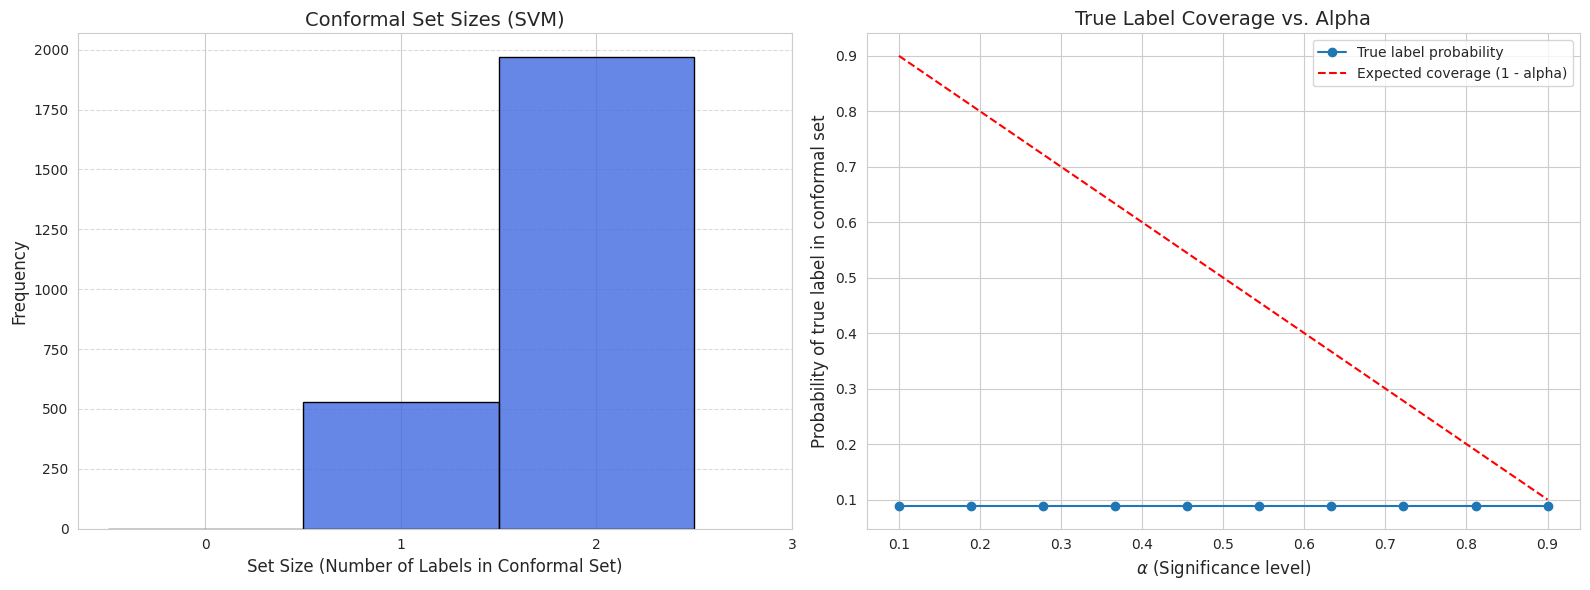

In [26]:
alpha = 0.3

for method in D:
    cl_cs_scores = D[method]['cl_cs']
    cl_att_scores = D[method]['cl_att']
    
    # Compute quantiles
    q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl
    qhat = np.quantile(cl_cs_scores, q_level, method='higher')
    qhat_A = np.quantile(cl_att_scores, q_level, method='higher')
    
    print(f'\nMethod: {method}')
    print('Classic quantile:', qhat)
    print('Attacked quantile:', qhat_A)

    # Create plots
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    axs[0].hist(cl_cs_scores, bins=10, edgecolor='black', alpha=0.7, label='Non-attacked')
    axs[0].axvline(x=qhat, color='red', linestyle='dotted', linewidth=2, label=f'q̂ = {qhat:.2f}')
    axs[0].set_title(f'{method} | Not-attacked Samples')
    axs[0].set_xlabel('Score Range')
    axs[0].set_ylabel('Frequency')
    axs[0].legend()

    axs[1].hist(cl_att_scores, bins=10, edgecolor='black', alpha=0.7, label='Attacked')
    axs[1].axvline(x=qhat_A, color='red', linestyle='dotted', linewidth=2, label=f'q̂_A = {qhat_A:.2f}')
    axs[1].set_title(f'{method} | Attacked Samples')
    axs[1].set_xlabel('Score Range')
    axs[1].legend()

    fig.suptitle(f'Score Distribution Comparison — Method: {method.upper()}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    att_conformal_sets, att_score_list = compute_CP(ts_att, qhat_A, svm, method)
    att_coverage = compute_covergae(ts, att_conformal_sets)

    att_coverage_var = compute_covergae_std(ts, att_conformal_sets)
    att_sizes = compute_set_sizes(ts, att_conformal_sets)

    att_size_mean = mean_conformal_sets(att_conformal_sets)
    att_size_var = std_conformal_sets(att_conformal_sets)

    plot_conformal_analysis(ts_att, ts, att_sizes, ts_att_scores,att_score_list, svm,  method = method , steps = 10, dataset_name = "SVM")

In [23]:
att_conformal_sets

[[0, 1],
 [0, 1],
 [1, 0],
 [0],
 [1, 0],
 [0, 1],
 [1],
 [1],
 [1],
 [0, 1],
 [1, 0],
 [0, 1],
 [1, 0],
 [0, 1],
 [0, 1],
 [0, 1],
 [1, 0],
 [1, 0],
 [0, 1],
 [0, 1],
 [1],
 [1, 0],
 [1, 0],
 [1, 0],
 [0, 1],
 [1, 0],
 [1, 0],
 [0, 1],
 [0, 1],
 [1, 0],
 [0, 1],
 [0],
 [1, 0],
 [1, 0],
 [1, 0],
 [0],
 [1, 0],
 [1, 0],
 [0],
 [0, 1],
 [1, 0],
 [1, 0],
 [0, 1],
 [1, 0],
 [1, 0],
 [1, 0],
 [0, 1],
 [0],
 [1, 0],
 [1, 0],
 [0, 1],
 [0, 1],
 [1, 0],
 [1, 0],
 [1, 0],
 [1, 0],
 [0, 1],
 [1, 0],
 [1, 0],
 [1, 0],
 [0],
 [1, 0],
 [1, 0],
 [1],
 [0],
 [1, 0],
 [0],
 [1],
 [1, 0],
 [1, 0],
 [0, 1],
 [0, 1],
 [1],
 [1, 0],
 [1, 0],
 [0, 1],
 [0, 1],
 [0, 1],
 [1],
 [1, 0],
 [0, 1],
 [0, 1],
 [0, 1],
 [0, 1],
 [1, 0],
 [0, 1],
 [0, 1],
 [0],
 [1, 0],
 [0, 1],
 [1, 0],
 [1, 0],
 [1, 0],
 [1, 0],
 [1],
 [1],
 [1],
 [0, 1],
 [0, 1],
 [0, 1],
 [0, 1],
 [1, 0],
 [1, 0],
 [1, 0],
 [0, 1],
 [1, 0],
 [0, 1],
 [1],
 [1, 0],
 [0, 1],
 [0, 1],
 [1, 0],
 [0, 1],
 [0],
 [1, 0],
 [0, 1],
 [0, 1],
 [0],
 [1, 0]

Classic quantile: 0.39154669007979503
Attacked quantile: 0.39154669007979503


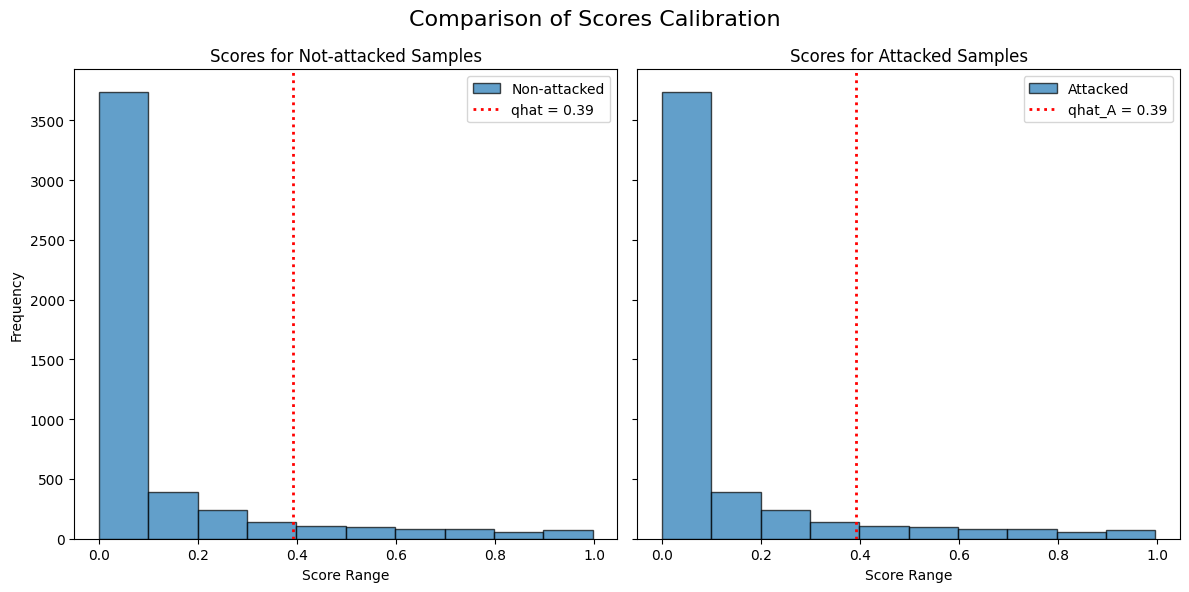

In [24]:
alpha = 0.1

q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl

qhat = np.quantile(cl_cs_scores, q_level, method='higher')
qhat_A = np.quantile(cl_att_scores, q_level, method='higher')

print('Classic quantile:', qhat)
print('Attacked quantile:', qhat_A)

fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axs[0].hist(cl_cs_scores, bins=10, edgecolor='black', alpha=0.7, label='Non-attacked')
axs[0].axvline(x=qhat, color='red', linestyle='dotted', linewidth=2, label=f'qhat = {qhat:.2f}')
axs[0].set_title('Scores for Not-attacked Samples')
axs[0].set_xlabel('Score Range')
axs[0].set_ylabel('Frequency')
axs[0].legend()

axs[1].hist(cl_att_scores, bins=10, edgecolor='black', alpha=0.7, label='Attacked')
axs[1].axvline(x=qhat_A, color='red', linestyle='dotted', linewidth=2, label=f'qhat_A = {qhat_A:.2f}')
axs[1].set_title('Scores for Attacked Samples')
axs[1].set_xlabel('Score Range')
axs[1].legend()

fig.suptitle(f'Comparison of Scores Calibration', fontsize=16)
plt.tight_layout()
plt.show()

Computing CP sets: 100%|██████████████████████████████████████| 2500/2500 [00:01<00:00, 1621.44it/s]


True label is in the conformal set for 0/2500 test samples (0.00%).
Coverage std (0.00).
Number of conformal sets with size 1: 2500
Average set size: 1.0
Std set size: 0.0
Plotting results...


Plotting calibration curve: 100%|██████████████████████████████████| 10/10 [00:00<00:00, 280.99it/s]


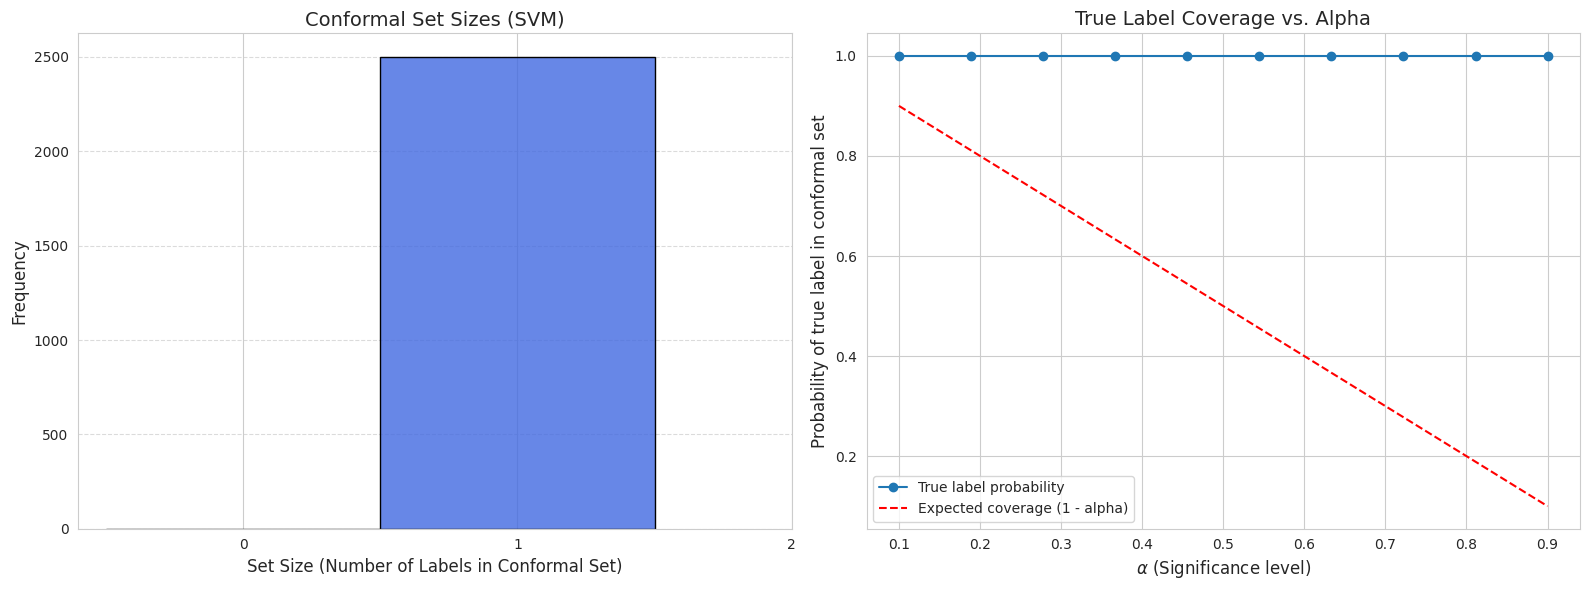

In [186]:
att_conformal_sets, score_list = compute_CP(ts_att, qhat, svm)
att_coverage = compute_covergae(ts, att_conformal_sets)

att_coverage_var = compute_covergae_std(ts, att_conformal_sets)
att_sizes = compute_set_sizes(ts, att_conformal_sets)

att_size_mean = mean_conformal_sets(att_conformal_sets)
att_size_var = std_conformal_sets(att_conformal_sets)

plot_conformal_analysis(ts_att, ts, att_sizes, cl_cs_scores, score_list, svm,  method = method, steps = 10, dataset_name = "SVM")

Computing CP sets: 100%|██████████████████████████████████████| 2500/2500 [00:01<00:00, 1663.62it/s]


True label is in the conformal set for 2500/2500 test samples (100.00%).
Coverage std (0.00).
Number of conformal sets with size 2: 2500
Average set size: 2.0
Std set size: 0.0
Plotting results...


Plotting calibration curve: 100%|██████████████████████████████████| 10/10 [00:00<00:00, 288.01it/s]


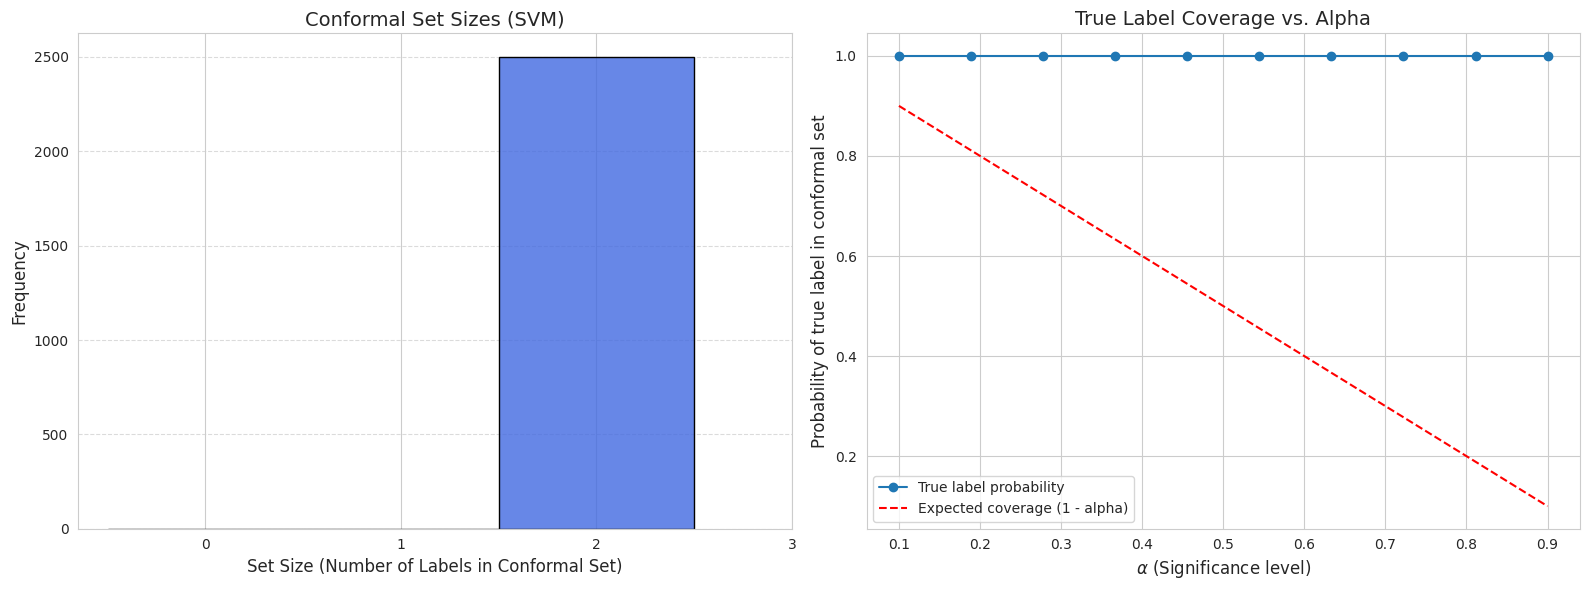

In [187]:
att_conformal_sets,att_score_list = compute_CP(ts_att, qhat_A, svm)
att_coverage = compute_covergae(ts, att_conformal_sets)

att_coverage_var = round(compute_covergae_std(ts, att_conformal_sets),2)
att_sizes = compute_set_sizes(ts, att_conformal_sets)

att_size_mean = mean_conformal_sets(att_conformal_sets)
att_size_var = std_conformal_sets(att_conformal_sets)

plot_conformal_analysis(ts_att, ts, att_sizes, cl_att_scores,att_score_list, svm,  method = method , steps = 10, dataset_name = "SVM")

In [ ]:
att_conformal_sets, score_list = compute_CP(ts_att, qhat, svm)
att_coverage = compute_covergae(ts, att_conformal_sets)

att_coverage_var = compute_covergae_std(ts, att_conformal_sets)
att_sizes = compute_set_sizes(ts, att_conformal_sets)

att_size_mean = mean_conformal_sets(att_conformal_sets)
att_size_var = std_conformal_sets(att_conformal_sets)

plot_conformal_analysis(ts_att, ts, att_sizes, cl_cs_scores, score_list, svm,  method = method, steps = 10, dataset_name = "SVM")

In [46]:
# Parameters
epsilon_values = np.linspace(0, 1.5, 2)  # Range of epsilon values to evaluate
conformal_set_sizes = []  # To store counts of size 0 conformal sets

alpha = 0.1

# Compute the quantile level once (since it's independent of epsilon)
q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl

stat = {}

for method in Method:
    
    Att_size_mean = []
    Att_size_var = []
    Att_coverage = []
    Att_coverage_var = []

    for eps in tqdm(epsilon_values, desc='Processing', unit='sample'):
    
        cl_att = list(attack_linear_SVM(cl.X, cl.Y.tondarray(), w.tondarray(), eps).tondarray())
        ts_att = list(attack_linear_SVM(ts.X, ts.Y.tondarray(), w.tondarray(), eps).tondarray())

        cl_att_scores = compute_score(cl, cl_att, svm, method)
        ts_att_scores = compute_score(ts, ts_att, svm, method)

        # Quantile of the attacked scores
        qhat_A = np.quantile(cl_att_scores, q_level, method='higher')

        # Compute conformal prediction sets
        att_conformal_sets, _ = compute_CP(ts_att, qhat, svm)

        att_coverage = compute_covergae(ts, att_conformal_sets)

        att_coverage_var = compute_covergae_std(ts, att_conformal_sets)
        att_sizes = compute_set_sizes(ts, att_conformal_sets)

        att_size_mean = mean_conformal_sets(att_conformal_sets)
        att_size_var = std_conformal_sets(att_conformal_sets)
        
        Att_size_mean.append(att_size_mean)
        Att_size_var.append(att_size_var)
        Att_coverage.append(att_coverage)
        Att_coverage_var.append(att_coverage_var)
    
    stat[method] = {
        'size_mean': Att_size_mean,
        'size_std': Att_size_var,
        'coverage_mean': Att_coverage,
        'coverage_std': Att_coverage_var,
    } 

  

Computing scores...: 100%|██████████| 5000/5000 [00:01<00:00, 2641.43sample/s]

Computing scores...: 100%|██████████| 2500/2500 [00:01<00:00, 2443.16sample/s]

Processing:  50%|█████     | 1/2 [00:04<00:04,  4.88s/sample]

True label is in the conformal set for 2500/2500 test samples (100.00%).
Coverage std (0.00).
Number of conformal sets with size 1: 37
Number of conformal sets with size 2: 2463
Average set size: 1.9852
Std set size: 0.12075164595151486



Computing scores...: 100%|██████████| 5000/5000 [00:01<00:00, 2539.47sample/s]

Computing scores...: 100%|██████████| 2500/2500 [00:00<00:00, 2560.26sample/s]

Processing: 100%|██████████| 2/2 [00:09<00:00,  4.86s/sample]


True label is in the conformal set for 0/2500 test samples (0.00%).
Coverage std (0.00).
Number of conformal sets with size 1: 2500
Average set size: 1.0
Std set size: 0.0


Computing scores...: 100%|██████████| 5000/5000 [00:01<00:00, 2502.96sample/s]

Computing scores...: 100%|██████████| 2500/2500 [00:01<00:00, 2389.58sample/s]

Processing:  50%|█████     | 1/2 [00:04<00:04,  4.92s/sample]

...

True label is in the conformal set for 0/2500 test samples (0.00%).
Coverage std (0.00).
Number of conformal sets with size 1: 2500
Average set size: 1.0
Std set size: 0.0


Computing scores...: 100%|██████████| 5000/5000 [00:02<00:00, 2469.10sample/s]

Computing scores...: 100%|██████████| 2500/2500 [00:01<00:00, 2467.83sample/s]

Processing:  50%|█████     | 1/2 [00:04<00:04,  4.96s/sample]

True label is in the conformal set for 2500/2500 test samples (100.00%).
Coverage std (0.00).
Number of conformal sets with size 1: 37
Number of conformal sets with size 2: 2463
Average set size: 1.9852
Std set size: 0.12075164595151486



Computing scores...: 100%|██████████| 5000/5000 [00:02<00:00, 2433.83sample/s]

Computing scores...: 100%|██████████| 2500/2500 [00:01<00:00, 2365.10sample/s]

Processing: 100%|██████████| 2/2 [00:09<00:00,  4.96s/sample]

True label is in the conformal set for 0/2500 test samples (0.00%).
Coverage std (0.00).
Number of conformal sets with size 1: 2500
Average set size: 1.0
Std set size: 0.0


In [47]:
stat

{'lac': {'size_mean': [1.9852, 1.0],
  'size_std': [0.12075164595151486, 0.0],
  'coverage_mean': [100.0, 0.0],
  'coverage_std': [0.0, 0.0]},
 'top-k': {'size_mean': [1.9852, 1.0],
  'size_std': [0.12075164595151486, 0.0],
  'coverage_mean': [100.0, 0.0],
  'coverage_std': [0.0, 0.0]},
 'aps': {'size_mean': [1.9852, 1.0],
  'size_std': [0.12075164595151486, 0.0],
  'coverage_mean': [100.0, 0.0],
  'coverage_std': [0.0, 0.0]}}

In [15]:
def svm_f_x_y(x, y):
    
    decision_scores_0 = svm.decision_function(x)[:, 0].tondarray()
    probabilities = platt_scaler.predict_proba(decision_scores_0.reshape(-1,1))
    f_x_y = probabilities[np.arange(len(y)), y]
    
    return f_x_y

In [16]:
def s(x,y):
    return 1 - svm_f_x_y(x,y)

In [17]:
def ap_s(x,y):
    
    
    decision_scores_0 = svm.decision_function(x)[:, 0].tondarray()

    probabilities = platt_scaler.predict_proba(decision_scores_0.reshape(-1,1))

    sorted_probabilities = np.sort(probabilities, axis = 1)[:, ::-1]

    summed_ranks = np.array([row[:label + 1].sum() for row, label in zip(sorted_probabilities, y)])

    return summed_ranks

In [18]:
def s(x,y, method = 'lac'):
    
    if method == 'lac':
        
        return 1 - svm_f_x_y(x,y)
    
    elif method  == 'aps':
        
        decision_scores_0 = svm.decision_function(x)[:, 0].tondarray()

        probabilities = platt_scaler.predict_proba(decision_scores_0.reshape(-1,1))

        sorted_probabilities = np.sort(probabilities, axis = 1)[:, ::-1]
        
        summed_ranks = np.array([row[:label + 1].sum() for row, label in zip(sorted_probabilities, y)])

        return summed_ranks

In [19]:
def s(x, y, clf, method = 'lac'):
    
    if method == 'lac':
    
        probabilities = clf.decision_function(x).tondarray()[0]

        return 1 - probabilities[int(y.tondarray()[0])]
        
    if method == 'aps':
        
        probabilities = clf.decision_function(x).tondarray()[0]
        
        # Rank labels by decreasing probability
        ranked_indices = np.argsort(probabilities)[::-1]
        # Sum probabilities until reaching the true label
        cum_sum = 0
        for k, label in enumerate(ranked_indices):
            cum_sum += probabilities[label]
            if label == int(y.tondarray()[0]):
                return cum_sum  # Return cumulative score at true label

        return 1.0  # Should never reach here

In [20]:
import numpy as np

# Assuming `decision_scores_0` is your decision function output for class 0
# and `y` contains the true labels (0 or 1).

x = cl.X[51,:]
y = cl.Y[51]
print(y)
decision_scores_0 = svm.decision_function(x)[:, 0].tondarray()

# Get probabilities using a calibrated Platt scaler
probabilities = platt_scaler.predict_proba(decision_scores_0.reshape(-1, 1))

print(probabilities)

# Initialize an array to store the APS scores
aps_scores = []

for prob, label in zip(probabilities, y):
    # Sort probabilities in decreasing order
    sorted_prob = np.sort(prob)[::-1]
    print(sorted_prob)
    # Find the position of the original label in the sorted array
    original_prob = prob[label]
    print(original_prob)
    sorted_index = np.where(sorted_prob == original_prob)[0][0]  # Find the index of the original label's probability
    print(sorted_index)
    # Compute the score as the sum of probabilities up to the sorted index
    aps_score = sorted_prob[:sorted_index + 1].sum()
    aps_scores.append(aps_score)

print(aps_scores)

CArray([1])
[[1.18163901e-09 9.99999999e-01]]
[9.99999999e-01 1.18163901e-09]
0.999999998818361
0
[0.999999998818361]


-2.9075193320646457

In [24]:
epsilon = .035
alpha = 0.1
method = 'lac'
q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl

# Compute scores for attacked and non-attacked samples
classic_scores = s(cl.X, cl.Y, svm ,method)  # Scores without attack
attacked_scores = s(attack_linear_SVM(cl.X, cl.Y, w.tondarray(), epsilon), cl.Y.tondarray(), svm, method)  # Scores after attack

# Quantiles

qhat = np.quantile(classic_scores, q_level, method='higher')
qhat_A = np.quantile(attacked_scores, q_level, method='higher')

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Histogram for non-attacked scores
axs[0].hist(classic_scores, bins=10, edgecolor='black', alpha=0.7, label='Non-attacked')
axs[0].axvline(x=qhat, color='red', linestyle='dotted', linewidth=2, label=f'qhat = {qhat:.2f}')
axs[0].set_title('Scores for Non-attacked Samples')
axs[0].set_xlabel('Score Range')
axs[0].set_ylabel('Frequency')
axs[0].legend()

# Histogram for attacked scores
axs[1].hist(attacked_scores, bins=10, edgecolor='black', alpha=0.7, label='Attacked')
axs[1].axvline(x=qhat_A, color='red', linestyle='dotted', linewidth=2, label=f'qhat_A = {qhat_A:.2f}')
axs[1].set_title('Scores for Attacked Samples')
axs[1].set_xlabel('Score Range')
axs[1].legend()

# Add an overall title and adjust layout
fig.suptitle(f'Comparison of Scores (epsilon={epsilon})', fontsize=16)
plt.tight_layout()
plt.show()

TypeError: <class 'NoneType'> should not be used for CDense indexing.

### Compute the Conformal Sets

In [47]:
def compute_CP(dataset, qhat, w = None , epsilon = None, iffattack = False, method = 'lac'):
    conformal_sets = []
    print(qhat)
    n = dataset.X.shape[0]
    n_class = len(np.unique(cl.Y.tondarray()))
    
    for i in range(n):
        
        if iffattack: 
            attacked_ts = attack_linear_SVM(dataset.X, dataset.Y.tondarray(), w.tondarray(), epsilon)

            x = attacked_ts[i,:]
        
        else:
            x = dataset.X[i,:]

     # Initialize the conformal set for this sample
        conformal_set = []
        
        if method == 'lac':

        # Check each class digit
            for d in (0, 1):
                # Compute the score function for the current digit
                scores = s(x, [d], method)

                # Add the digit to the conformal set if the score satisfies the threshold
                if scores <= qhat:
                    conformal_set.append(d)
                    
        elif method == 'aps':
            # Calculate decision scores for class 0
            decision_scores_0 = svm.decision_function(x)[:, 0].tondarray()

            # Get probabilities using the Platt scaler
            probabilities = platt_scaler.predict_proba(decision_scores_0.reshape(-1, 1))
            
            conformal_set = []
            for prob in probabilities:
                # Sort probabilities in decreasing order
                sorted_prob = np.sort(prob)[::-1]

                summed_ranks = 0
                for j in range(n_class):
                    summed_ranks += sorted_prob[j]
                    # Stop adding classes once the cumulative sum exceeds qhat
                    if summed_ranks > qhat:
                        break
                    else:
                        # Add the current class to the conformal set
                        conformal_set.append(np.argmax(prob == sorted_prob[j]))
        # Store the conformal set for this sample
        conformal_sets.append(conformal_set)
    
    return conformal_sets

In [48]:
def evaluate_conformal_sets(dataset, conformal_sets):
    
    # %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% COVERAGE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%% #
    true_label_in_conformal_set = []
    n = dataset.X.shape[0]  # Assuming `dataset` is a list or similar iterable
    
    for i in range(n):
        y0 = dataset[i,:].Y
        conformal_set = conformal_sets[i]
        true_label_in_conformal_set.append(y0 in conformal_set)

    n_correct = sum(true_label_in_conformal_set)
    accuracy = n_correct / n * 100
    
    print(f"True label is in the conformal set for {n_correct}/{n} test samples ({accuracy:.2f}%).")

    # %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SETS SIZE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%% #
    conformal_set_sizes = [len(conformal_set) for conformal_set in conformal_sets]

    count_0 = conformal_set_sizes.count(0)
    count_1 = conformal_set_sizes.count(1)
    count_2 = conformal_set_sizes.count(2)

    print(f"Number of conformal sets with size 0: {count_0}")
    print(f"Number of conformal sets with size 1: {count_1}")
    print(f"Number of conformal sets with size 2: {count_2}")

    return accuracy, count_0, count_1, count_2


In [73]:
def plot_calibration_curve(dataset, scores, cl, w, epsilon, iffattack, method):
    
    test_scores = []
    true_labels = []
    
    n = dataset.X.shape[0]
    n_cl = cl.X.shape[0]
    n_class = 2
    
    if iffattack:
        data = attack_linear_SVM(dataset.X, dataset.Y.tondarray(), w.tondarray(), epsilon)
    else:
        data = dataset.X
   
    for i in range(n):
        true_labels.append(dataset[i, :].Y)
        test_scores.append([s(data[i, :], [d], method) for d in (0, 1)])

    test_scores = np.array(test_scores)
    true_labels = np.array(true_labels)

    alphas = np.linspace(0.01, 0.9, 50)
    probabilities = []

    for alpha in alphas:
        q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl
        qhat = np.quantile(scores, q_level, method='higher')

        if method  == 'lac':
        
            conformal_Sets = test_scores <= qhat
            
        elif method == 'aps':
            
            conformal_Sets = []
            
            for k in range(n):
                x = data[k, :]
                # Calculate decision scores for class 0
                decision_scores_0 = svm.decision_function(x)[:, 0].tondarray()

                # Get probabilities using the Platt scaler
                probabilities = platt_scaler.predict_proba(decision_scores_0.reshape(-1, 1))

                conformal_set = []
                for prob in probabilities:
                    # Sort probabilities in decreasing order
                    sorted_prob = np.sort(prob)[::-1]

                    summed_ranks = 0
                    for j in range(n_class):
                        summed_ranks += sorted_prob[j]
                        # Stop adding classes once the cumulative sum exceeds qhat
                        if summed_ranks > qhat:
                            break
                        else:
                            # Add the current class to the conformal set
                            conformal_set.append(np.argmax(prob == sorted_prob[j]))
            # Store the conformal set for this sample
                conformal_Sets.append(conformal_set)
                
        print(conformal_Sets)
        true_label_in_conformal_set = [
            conformal_Sets[i, (0, 1).index(y)] for i, y in enumerate(true_labels)
        ]
        n_correct = sum(true_label_in_conformal_set)
        probability = n_correct / n
        probabilities.append(probability)
        
    return probabilities, alphas

In [61]:
def plot_conformal(dataset, conformal_sets, scores, cl = cl, w = w, epsilon = epsilon, iffattack=False, method = 'lac'):
    
    conformal_set_sizes = [len(conformal_set) for conformal_set in conformal_sets]

    # Ensure we include a bin for 0 class size
    conformal_set_sizes = [0 if size == 0 else size for size in conformal_set_sizes]
    probabilities, alphas = plot_calibration_curve(dataset, scores, cl, w, epsilon, iffattack, method)
            
    # %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% PLOTTING SUBPLOTS %%%%%%%%%%%%%%%%%%%%%%%%%%%%%% #

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Histogram of conformal set sizes with 0 class size bin colored red
    bins = np.arange(0, max(conformal_set_sizes) + 2) - 0.5  # Add 0 bin
    axes[0].hist(conformal_set_sizes, bins=bins, edgecolor='black', rwidth=0.8, color='blue')
    
    # Color the bin for size 0 in red
    axes[0].patches[0].set_facecolor('red')
    
    axes[0].set_title("Conformal Set Sizes", fontsize=14)
    axes[0].set_xlabel("Set Size (Number of Labels in Conformal Set)", fontsize=12)
    axes[0].set_ylabel("Frequency", fontsize=12)
    axes[0].set_xticks(np.arange(0, max(conformal_set_sizes) + 2))
    
    # Plot 2: Calibration curve
    axes[1].plot(alphas, probabilities, marker='o', label='True label probability')
    axes[1].plot(alphas, 1 - alphas, color='r', linestyle='--', label='Expected coverage (1 - alpha)')
    axes[1].set_xlabel(r'$\alpha$ (Significance level)', fontsize=12)
    axes[1].set_ylabel('Probability of true label in conformal set', fontsize=12)
    axes[1].set_title('True Label Coverage vs. Alpha', fontsize=14)
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## Classic

In [75]:
scores_cl = s(cl.X, cl.Y.tondarray(), method)

conformal_sets_classic = compute_CP(ts, qhat, method = method)
_,_,_,_ = evaluate_conformal_sets(ts, conformal_sets_classic)

plot_conformal(ts, conformal_sets_classic, scores_cl,method = method)

0.9999999856895716
True label is in the conformal set for 2230/2500 test samples (89.20%).
Number of conformal sets with size 0: 263
Number of conformal sets with size 1: 2237
Number of conformal sets with size 2: 0
[[0], [0], [1], [0], [1], [0], [1], [1], [1], [0], [0], [1], [1], [0], [0], [0], [1], [1], [0], [0], [], [1], [1], [1], [0], [0], [1], [0], [0], [1], [0], [0], [1], [1], [0], [0], [1], [1], [0], [0], [1], [1], [0], [1], [1], [1], [0], [0], [1], [1], [0], [0], [1], [1], [1], [1], [0], [0], [1], [1], [0], [0], [1], [1], [0], [1], [0], [1], [1], [1], [0], [0], [1], [1], [1], [0], [0], [0], [1], [1], [0], [0], [0], [0], [1], [0], [0], [0], [0], [0], [1], [0], [1], [1], [1], [1], [1], [0], [0], [0], [0], [1], [1], [1], [0], [1], [1], [1], [1], [0], [0], [1], [0], [0], [1], [0], [0], [0], [1], [1], [1], [1], [0], [0], [0], [0], [0], [1], [0], [1], [1], [0], [0], [0], [1], [1], [1], [1], [0], [0], [0], [1], [0], [0], [1], [1], [0], [0], [1], [1], [0], [1], [0], [0], [1], [1], [0],

TypeError: list indices must be integers or slices, not tuple

## Attack

1.0
True label is in the conformal set for 2500/2500 test samples (100.00%).
Number of conformal sets with size 0: 0
Number of conformal sets with size 1: 0
Number of conformal sets with size 2: 2500


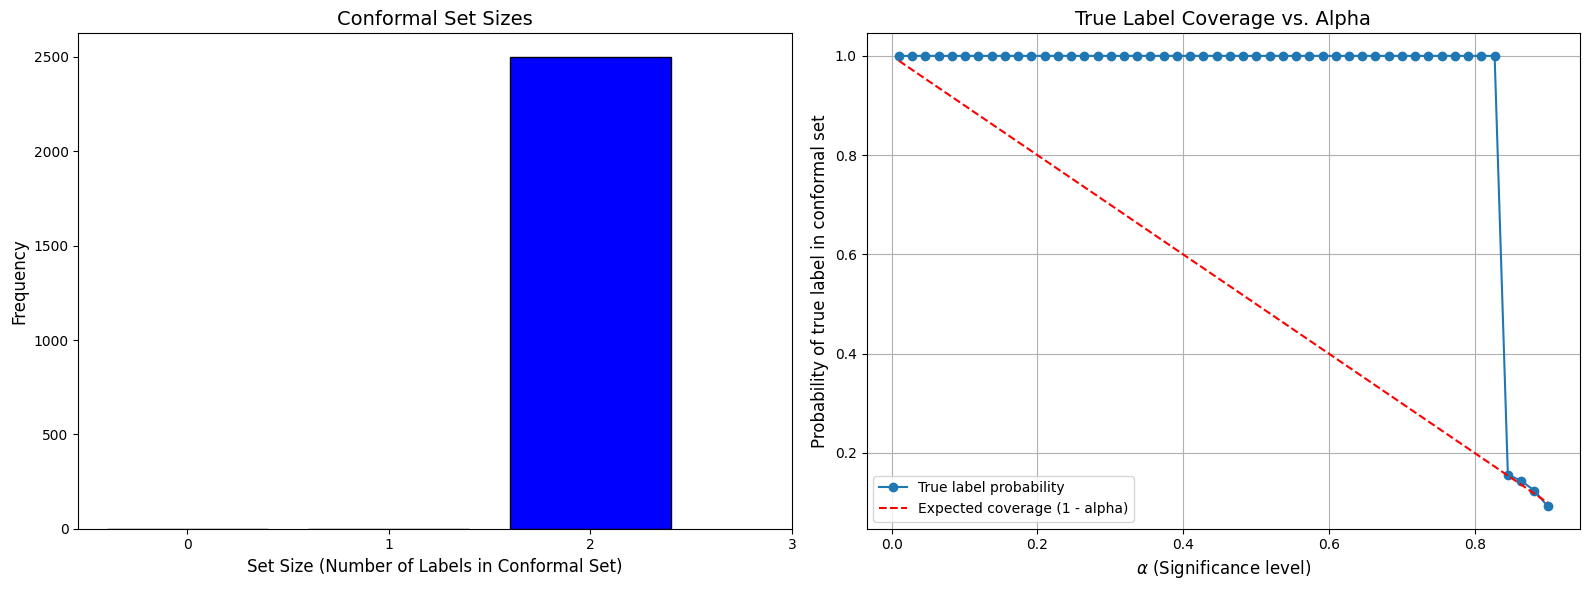

In [53]:
attacked_cl = attack_linear_SVM(cl.X, cl.Y.tondarray(), w.tondarray(), epsilon)
attacked_scores_cl = s(attacked_cl, cl.Y.tondarray(), method)

conformal_sets_attack = compute_CP(ts, qhat_A, w, epsilon, True, method )
_,_,_,_ = evaluate_conformal_sets(ts, conformal_sets_attack)

plot_conformal(ts, conformal_sets_attack, attacked_scores_cl, cl, w, epsilon, iffattack=True, method = method)

## Attacked samples - Classic CP

0.9999999856895716
True label is in the conformal set for 2497/2500 test samples (99.88%).
Number of conformal sets with size 0: 0
Number of conformal sets with size 1: 3
Number of conformal sets with size 2: 2497


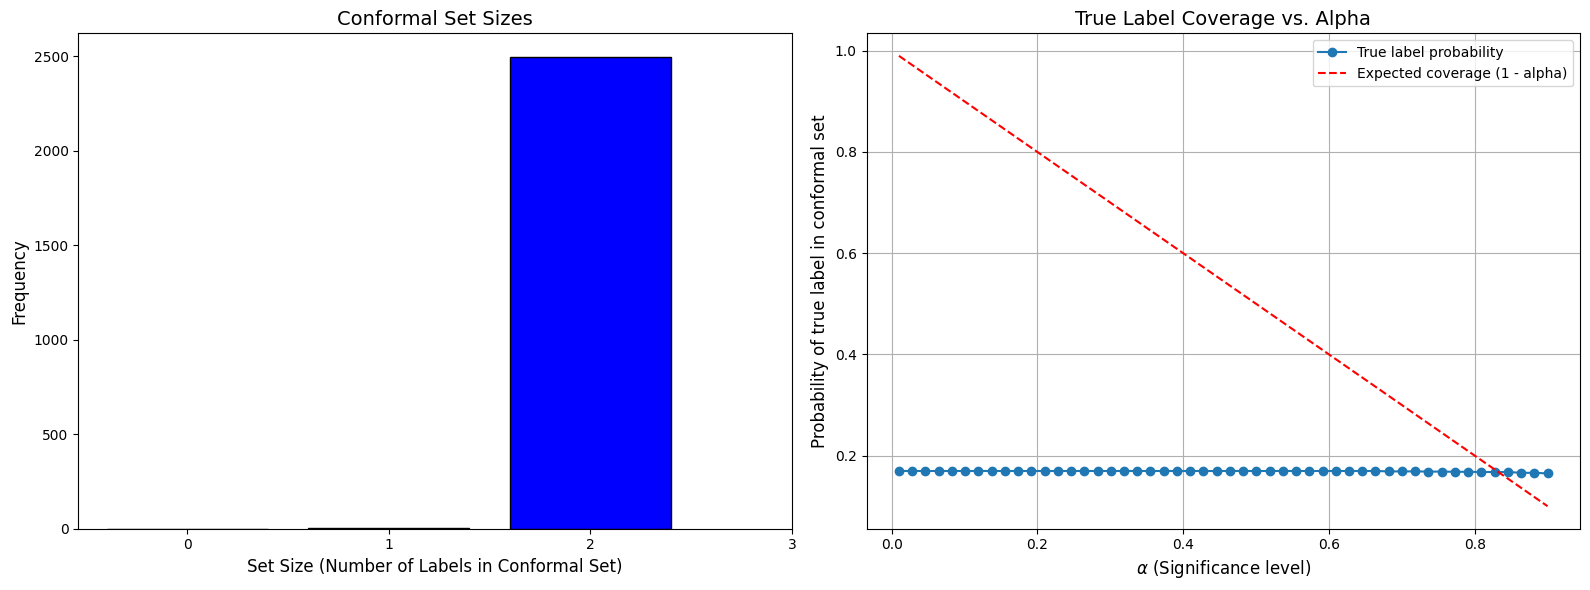

In [54]:
scores_cl = s(cl.X, cl.Y.tondarray(),method)

conformal_sets_att_cls = compute_CP(ts, qhat, w, epsilon, True)
_,_,_,_ = evaluate_conformal_sets(ts, conformal_sets_att_cls)

plot_conformal(ts, conformal_sets_att_cls, scores_cl,  cl, w, epsilon, iffattack = True, method = method)

## Not attacked samples - Attacked CP

0.9999568796778762
True label is in the conformal set for 2500/2500 test samples (100.00%).
Number of conformal sets with size 0: 0
Number of conformal sets with size 1: 1808
Number of conformal sets with size 2: 692


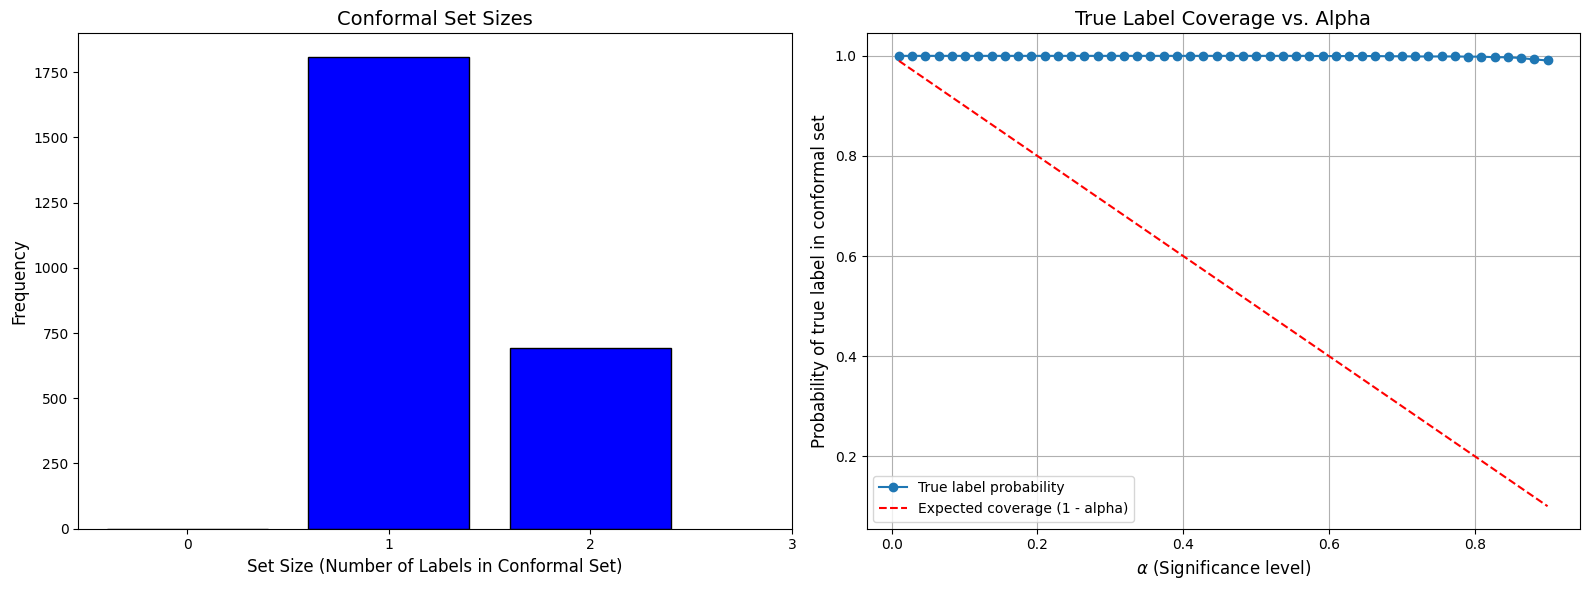

In [88]:
conformal_sets_cls_att = compute_CP(ts, qhat_A, w, epsilon, False)

_,_,_,_ = evaluate_conformal_sets(ts, conformal_sets_cls_att)

plot_conformal(ts, conformal_sets_cls_att, attacked_scores_cl,  cl, w, epsilon, iffattack = False, method = method)

## Other plots

Processing: 100%|██████████| 50/50 [02:34<00:00,  3.10s/sample]


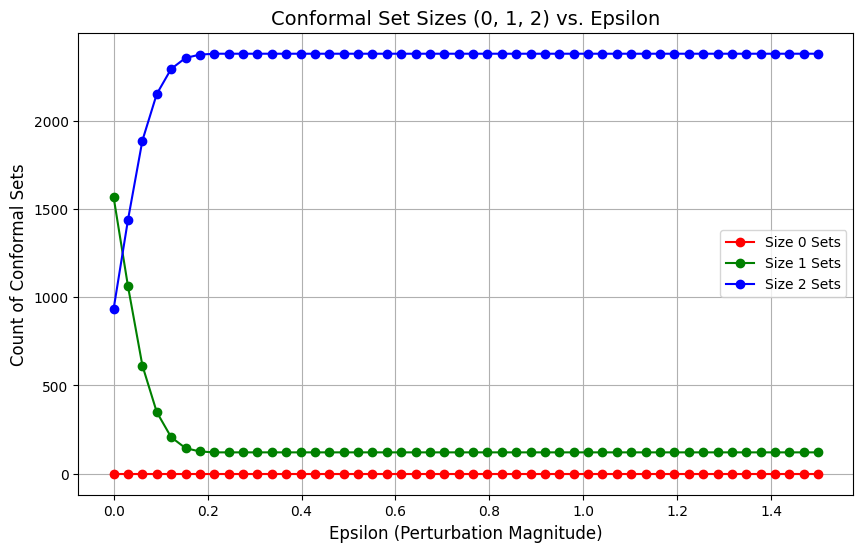

In [83]:
# Parameters
epsilon_values = np.linspace(0, 1.5, 50)  # Range of epsilon values to evaluate
conformal_set_sizes_0 = []  # To store counts of size 0 conformal sets
conformal_set_sizes_1 = []  # To store counts of size 1 conformal sets
conformal_set_sizes_2 = []  # To store counts of size 2 conformal sets

alpha = 0.05

# Compute the quantile level once (since it's independent of epsilon)
q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl

# Loop over epsilon values with a progress bar
for epsilon in tqdm(epsilon_values, desc='Processing', unit='sample'):
    # Compute scores after attack
    attacked_scores = s(
        attack_linear_SVM(cl.X, cl.Y.tondarray(), w.tondarray(), epsilon),
        cl.Y.tondarray(), method
    )
    
    # Quantile of the attacked scores
    qhat_A = np.quantile(attacked_scores, q_level, method='higher')
    
    # Compute conformal prediction sets
    conformal_sets = compute_CP(ts, qhat_A, w=w, epsilon=epsilon, iffattack=True)
    
    # Record the sizes of the conformal sets
    conformal_set_sizes = [len(conformal_set) for conformal_set in conformal_sets]
    
    # Count the number of sets of size 0, 1, and 2
    count_0 = conformal_set_sizes.count(0)
    count_1 = conformal_set_sizes.count(1)
    count_2 = conformal_set_sizes.count(2)
    
    # Append the counts to the corresponding lists
    conformal_set_sizes_0.append(count_0)
    conformal_set_sizes_1.append(count_1)
    conformal_set_sizes_2.append(count_2)

# Plot the counts of conformal set sizes (0, 1, and 2) as a function of epsilon
plt.figure(figsize=(10, 6))

# Plot each of the counts as separate curves
plt.plot(epsilon_values, conformal_set_sizes_0, marker='o', label="Size 0 Sets", color='r')
plt.plot(epsilon_values, conformal_set_sizes_1, marker='o', label="Size 1 Sets", color='g')
plt.plot(epsilon_values, conformal_set_sizes_2, marker='o', label="Size 2 Sets", color='b')

# Customize plot appearance
plt.xlabel("Epsilon (Perturbation Magnitude)", fontsize=12)
plt.ylabel("Count of Conformal Sets", fontsize=12)
plt.title("Conformal Set Sizes (0, 1, 2) vs. Epsilon", fontsize=14)
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


Processing: 100%|██████████| 50/50 [02:34<00:00,  3.09s/sample]


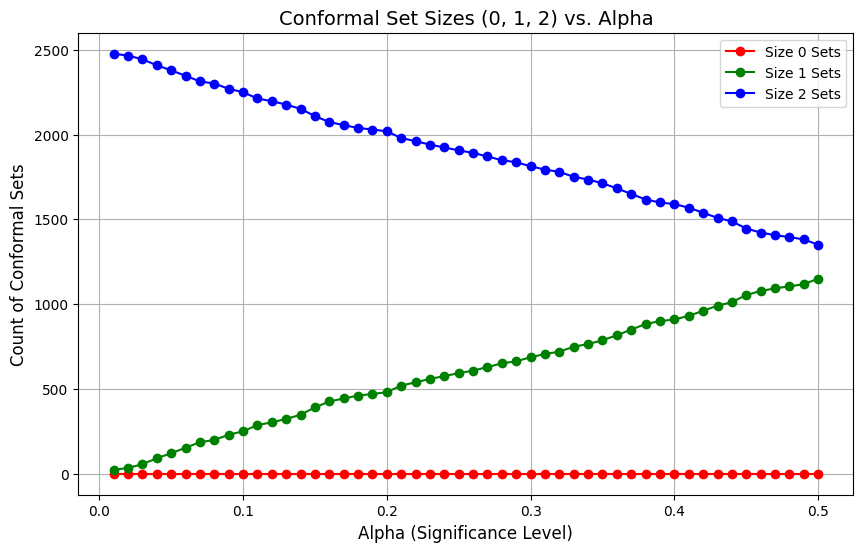

In [82]:
# Parameters
alpha_values = np.linspace(0.01, 0.5, 50)  # Range of alpha values to evaluate
conformal_set_sizes_0 = []  # To store counts of size 0 conformal sets
conformal_set_sizes_1 = []  # To store counts of size 1 conformal sets
conformal_set_sizes_2 = []  # To store counts of size 2 conformal sets

epsilon = 0.35  # Fixed epsilon value

# Loop over alpha values with a progress bar
for alpha in tqdm(alpha_values, desc='Processing', unit='sample'):
    # Compute the quantile level for the current alpha
    q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl
    
    # Compute scores after attack (epsilon is fixed)
    attacked_scores = s(
        attack_linear_SVM(cl.X, cl.Y.tondarray(), w.tondarray(), epsilon),
        cl.Y.tondarray(), method
    )
    
    # Quantile of the attacked scores
    qhat_A = np.quantile(attacked_scores, q_level, method='higher')
    
    # Compute conformal prediction sets
    conformal_sets = compute_CP(ts, qhat_A, w=w, epsilon=epsilon, iffattack=True)
    
    # Record the sizes of the conformal sets
    conformal_set_sizes = [len(conformal_set) for conformal_set in conformal_sets]
    
    # Count the number of sets of size 0, 1, and 2
    count_0 = conformal_set_sizes.count(0)
    count_1 = conformal_set_sizes.count(1)
    count_2 = conformal_set_sizes.count(2)
    
    # Append the counts to the corresponding lists
    conformal_set_sizes_0.append(count_0)
    conformal_set_sizes_1.append(count_1)
    conformal_set_sizes_2.append(count_2)

# Plot the counts of conformal set sizes (0, 1, and 2) as a function of alpha
plt.figure(figsize=(10, 6))

# Plot each of the counts as separate curves
plt.plot(alpha_values, conformal_set_sizes_0, marker='o', label="Size 0 Sets", color='r')
plt.plot(alpha_values, conformal_set_sizes_1, marker='o', label="Size 1 Sets", color='g')
plt.plot(alpha_values, conformal_set_sizes_2, marker='o', label="Size 2 Sets", color='b')

# Customize plot appearance
plt.xlabel("Alpha (Significance Level)", fontsize=12)
plt.ylabel("Count of Conformal Sets", fontsize=12)
plt.title("Conformal Set Sizes (0, 1, 2) vs. Alpha", fontsize=14)
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


Processing: 100%|██████████| 50/50 [02:40<00:00,  3.21s/sample]


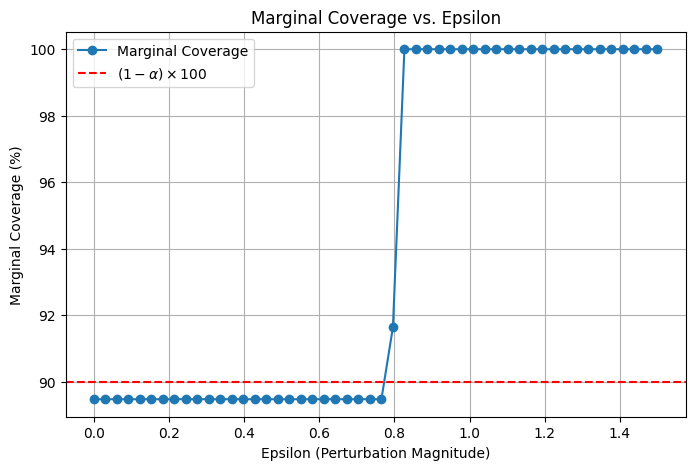

In [36]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# Parameters
epsilon_values = np.linspace(0, 1.5, 50)  # Range of epsilon values to evaluate
marginal_coverages = []

alpha = 0.1
n_cl = cl.X.shape[0]  # Number of calibration points

# Compute the quantile level once (since it's independent of epsilon)
q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl

# Loop over epsilon values with a progress bar
for epsilon in tqdm(epsilon_values, desc='Processing', unit='sample'):
    # Compute scores after attack
    attacked_scores = s(
        attack_linear_SVM(cl.X, cl.Y.tondarray(), w.tondarray(), epsilon),
        cl.Y.tondarray(),'aps'
    )
    
    # Quantile of the attacked scores
    qhat_A = np.quantile(attacked_scores, q_level, method='higher')
    
    # Compute conformal prediction sets
    conformal_sets = compute_CP(ts, qhat_A, w=w, epsilon=epsilon, iffattack=True)
    
    # Check if true labels are in the conformal sets
    true_label_in_conformal_set = [
        ts[i, :].Y in conformal_sets[i] for i in range(n_ts)
    ]
    
    # Compute marginal coverage as a percentage
    coverage = sum(true_label_in_conformal_set) / n_ts * 100
    marginal_coverages.append(coverage)

# Plot the marginal coverage as a function of epsilon
plt.figure(figsize=(8, 5))
plt.plot(epsilon_values, marginal_coverages, marker='o', label="Marginal Coverage")
plt.xlabel("Epsilon (Perturbation Magnitude)")
plt.axhline((1 - alpha) * 100, color='red', linestyle='--', label=r"$(1-\alpha) \times 100$")
plt.ylabel("Marginal Coverage (%)")
plt.title("Marginal Coverage vs. Epsilon")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
'''test_scores = []
true_labels = []
cl_attacked_scores = s(attack_linear_SVM(cl.X, cl.Y.tondarray(), w.tondarray(), epsilon), cl.Y.tondarray())  # Scores after attack

for i in range(n_ts):
    true_labels.append(ts[i, :].Y)  
    test_scores.append([s(attacked_ts[i,:], [d]) for d in (0,1)]) 
    
test_scores = np.array(test_scores)  
true_labels = np.array(true_labels)

alphas = np.linspace(0.01, 0.9, 50)
probabilities = []

for alpha in alphas:
    q_level = np.ceil((n_cl + 1) * (1 - alpha)) / n_cl
    qhat_A = np.quantile(cl_attacked_scores, q_level, method='higher')
    
    conformal_sets = test_scores <= qhat_A  
    true_label_in_conformal_set = [
        conformal_sets[i, (0,1).index(y)] for i, y in enumerate(true_labels)
    ]    
    n_correct = sum(true_label_in_conformal_set)
    probability = n_correct / n_ts
    probabilities.append(probability)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(alphas, probabilities, marker='o', label='True label probability')
plt.plot(alphas, 1 - alphas, color='r', linestyle='--', label='Expected coverage (1 - alpha)')
plt.xlabel(r'$\alpha$ (Significance level)', fontsize=12)
plt.ylabel('Probability of true label in conformal set', fontsize=12)
plt.title('True Label Coverage vs. Alpha', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()
'''